# Following Galectin-3 through OptimusKG

## A progressive tutorial in evidence navigation and graph thinking

This notebook supports the first of a proposed two-part series:

1. **Part 1 — Galectin-3:** What does OptimusKG record around `LGALS3`, and what changes when we examine typed relationships rather than a flat list of search results?
2. **Part 2 — Sterile inflammation:** Can an expert-reviewed biological module and topology-matched background help prioritise compounds or targets for further investigation?

The first notebook deliberately stops before causal inference or link prediction. It teaches how to resolve an entity, load only relevant graph layers, inspect evidence, construct a bounded projection, and calculate a simple graph similarity measure.

### Central question

> What disease, drug, pathway and biological-process context is directly recorded around Galectin-3, and which interacting genes have the most similar process neighbourhoods?

### What this notebook may establish

- recorded OptimusKG relationships and their provenance;
- derived properties of a clearly defined graph projection;
- candidate terms and connections for review.

It does **not** establish that Galectin-3 causes a disease, that a compound treats a disease, or that a shared biological process is an active mechanism.


## Why start here?

Gene-centred discovery systems such as KnetMiner show that a useful first knowledge-graph workflow is often **search → inspect evidence → restrict the subgraph → compare candidates**, rather than immediately fitting a predictive model. RPath provides a suitable later destination, but it requires signed causal interactions plus drug-perturbation and disease transcriptomic signatures.

This notebook therefore introduces four concepts in a modest order:

1. entity resolution;
2. typed neighbourhoods;
3. evidence-aware graph projection;
4. neighbourhood overlap as a simple graph-theoretic comparison.

The final section creates candidate sterile-inflammation terms for human review. It does not silently convert a keyword search into a biological definition.


## 1. Setup


In [2]:
# In a fresh Codespace run this once, then restart the kernel:
# %pip install -r requirements.txt

from pathlib import Path
import sys
import json
import re
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import polars as pl
from IPython.display import display
import core
import requests
import optimuskg._dataverse as dataverse

session = requests.Session()

session.headers.update(
    {
    "User-Agent": "Mozilla/5.0"
}
)

dataverse.requests = session


PROJECT_ROOT = Path.cwd().resolve()

'''
# Support either:
#   project/core.py
# or:
#   project/optimus_explorer/core.py
for candidate in [PROJECT_ROOT, PROJECT_ROOT / "optimus_explorer"]:
    if (candidate / "core.py").exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from core import OptimusExplorer
'''

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "galectin3_tutorial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(12)

polars.config.Config

## 2. Connect without loading the graph

Pinning a DOI makes the analysis reproducible. Set `OPTIMUSKG_DOI = None` to use the release configured by the installed client instead.


In [3]:
from core import OptimusExplorer

OPTIMUSKG_DOI = "doi:10.7910/DVN/IYNGEV"

kg = OptimusExplorer.from_optimuskg(doi=OPTIMUSKG_DOI)
display(kg.status())


measure,value
str,str
"""server""","""https://dataverse.harvard.edu"""
"""doi""","""doi:10.7910/DVN/IYNGEV"""
"""cache directory""","""/home/codespace/.cache/optimus…"
"""loaded tables""","""0"""
"""active tables""","""0"""


The catalogue describes what *could* be loaded. It does not download those tables. This is the graph equivalent of looking at a data dictionary before reading a large collection of files.


dataset,kind,path,source_type,target_type,label,loaded,active
str,str,str,str,str,str,bool,bool
"""anatomy""","""node""","""nodes/anatomy.parquet""",null,null,"""ANA""",false,false
"""biological_process""","""node""","""nodes/biological_process.parqu…",null,null,"""BPO""",false,false
"""cellular_component""","""node""","""nodes/cellular_component.parqu…",null,null,"""CCO""",false,false
"""disease""","""node""","""nodes/disease.parquet""",null,null,"""DIS""",false,false
"""drug""","""node""","""nodes/drug.parquet""",null,null,"""DRG""",false,false
"""exposure""","""node""","""nodes/exposure.parquet""",null,null,"""EXP""",false,false
"""gene""","""node""","""nodes/gene.parquet""",null,null,"""GEN""",false,false
"""molecular_function""","""node""","""nodes/molecular_function.parqu…",null,null,"""MFN""",false,false
"""pathway""","""node""","""nodes/pathway.parquet""",null,null,"""PWY""",false,false


dataset,source_type,target_type,label,loaded
str,str,str,str,bool
"""anatomy_anatomy""","""anatomy""","""anatomy""","""ANA-ANA""",false
"""anatomy_gene""","""anatomy""","""gene""","""ANA-GEN""",false
"""biological_process_biological_…","""biological_process""","""biological_process""","""BPO-BPO""",false
"""biological_process_gene""","""biological_process""","""gene""","""BPO-GEN""",false
"""cellular_component_cellular_co…","""cellular_component""","""cellular_component""","""CCO-CCO""",false
"""cellular_component_gene""","""cellular_component""","""gene""","""CCO-GEN""",false
"""disease_disease""","""disease""","""disease""","""DIS-DIS""",false
"""disease_gene""","""disease""","""gene""","""DIS-GEN""",false
"""disease_phenotype""","""disease""","""phenotype""","""DIS-PHE""",false


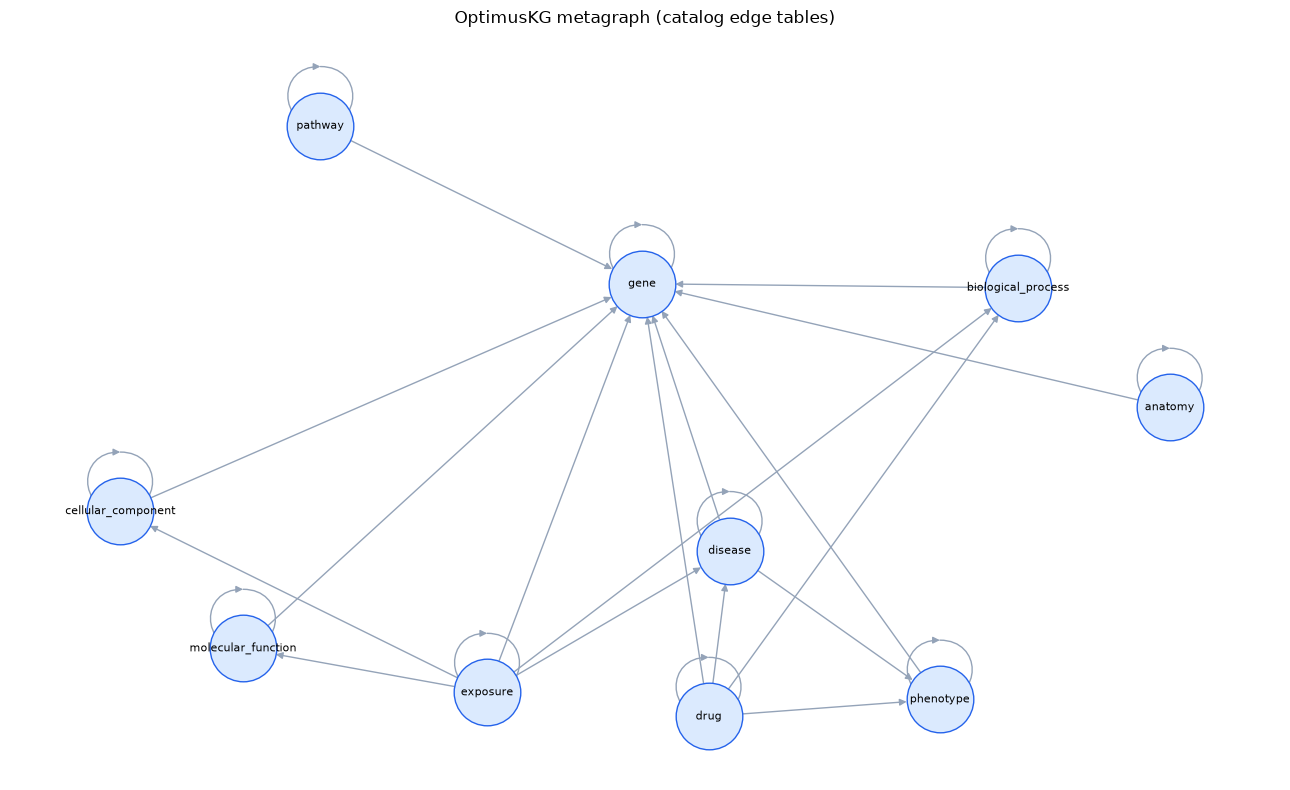

In [4]:
display(kg.catalog(kind="node"))
display(kg.catalog(kind="edge").select(
    "dataset", "source_type", "target_type", "label", "loaded"
))

# The complete type-level schema can be viewed before any data is loaded.
kg.plot_metagraph(scope="catalog")
plt.show()


## 3. Resolve Galectin-3 before following edges


In [5]:
kg.load_node("gene")

display(kg.search("Galectin-3", node_type="gene", limit=20))
display(kg.search("LGALS3", node_type="gene", limit=20))


node_type,id,name
str,str,str
"""gene""","""ENSG00000108679""","""galectin 3 binding protein"""
"""gene""","""ENSG00000131981""","""galectin 3"""
"""gene""","""ENSG00000204347""","""BTB domain containing 17"""


node_type,id,name
str,str,str
"""gene""","""ENSG00000108679""","""galectin 3 binding protein"""
"""gene""","""ENSG00000131981""","""galectin 3"""
"""gene""","""ENSG00000204347""","""BTB domain containing 17"""


Substring search can return related genes or synonym matches. For the tutorial we resolve the reviewed Ensembl identifier explicitly. Record this decision: entity resolution is part of the analysis, not clerical housekeeping.


In [6]:
LGALS3_ID = "ENSG00000131981"
lgals3 = kg.entity("gene", LGALS3_ID)
display(lgals3.info())
display(lgals3.properties())
display(lgals3.available_edge_types())


node_type,id,name,label
str,str,str,str
"""gene""","""ENSG00000131981""","""galectin 3""","""GEN"""


id,label,properties__symbol,properties__biotype,properties__transcript_ids,properties__canonical_exons,…,properties__genomic_location__end,properties__genomic_location__strand,properties__target_enabling_package__target_from_source_id,properties__target_enabling_package__description,properties__target_enabling_package__therapeutic_area,properties__target_enabling_package__url
str,str,str,str,list[str],list[str],…,i64,i64,null,null,null,null
"""ENSG00000131981""","""GEN""","""LGALS3""","""protein_coding""","[""ENST00000553493"", ""ENST00000556263"", … ""ENST00000556322""]","[""55137370"", ""55137391"", … ""55142749""]",…,55145423,1,null,null,null,null


dataset,source_type,target_type,label,loaded,active
str,str,str,str,bool,bool
"""anatomy_gene""","""anatomy""","""gene""","""ANA-GEN""",false,false
"""biological_process_gene""","""biological_process""","""gene""","""BPO-GEN""",false,false
"""cellular_component_gene""","""cellular_component""","""gene""","""CCO-GEN""",false,false
"""disease_gene""","""disease""","""gene""","""DIS-GEN""",false,false
"""drug_gene""","""drug""","""gene""","""DRG-GEN""",false,false
"""exposure_gene""","""exposure""","""gene""","""EXP-GEN""",false,false
"""gene_gene""","""gene""","""gene""","""GEN-GEN""",false,false
"""molecular_function_gene""","""molecular_function""","""gene""","""MFN-GEN""",false,false
"""pathway_gene""","""pathway""","""gene""","""PWY-GEN""",false,false


`lgals3` is a lightweight handle to the existing OptimusKG node, not a copy of
its whole neighbourhood. `info()` shows its identity, `properties()` exposes
the node record, and `available_edge_types()` shows documented relationship
tables that could be loaded. Edges are retrieved only when requested.


## 4. Plan and progressively load only relevant relationships


In [7]:
for destination in ["biological_process", "pathway", "disease", "drug"]:
    print(f"Schema route: gene → {destination}")
    display(kg.plan_path("gene", destination, max_hops=2).show())


Schema route: gene → biological_process


step,kind,dataset,path,loaded
i64,str,str,str,bool
0,"""node""","""gene""","""nodes/gene.parquet""",true
1,"""edge""","""biological_process_gene""","""edges/biological_process_gene.…",false
2,"""node""","""biological_process""","""nodes/biological_process.parqu…",false


Schema route: gene → pathway


step,kind,dataset,path,loaded
i64,str,str,str,bool
0,"""node""","""gene""","""nodes/gene.parquet""",true
1,"""edge""","""pathway_gene""","""edges/pathway_gene.parquet""",false
2,"""node""","""pathway""","""nodes/pathway.parquet""",false


Schema route: gene → disease


step,kind,dataset,path,loaded
i64,str,str,str,bool
0,"""node""","""gene""","""nodes/gene.parquet""",true
1,"""edge""","""disease_gene""","""edges/disease_gene.parquet""",false
2,"""node""","""disease""","""nodes/disease.parquet""",false


Schema route: gene → drug


step,kind,dataset,path,loaded
i64,str,str,str,bool
0,"""node""","""gene""","""nodes/gene.parquet""",true
1,"""edge""","""drug_gene""","""edges/drug_gene.parquet""",false
2,"""node""","""drug""","""nodes/drug.parquet""",false


The disease–gene table is large. Loading it is an intentional analytical choice because the blog question includes the Galectin-3 disease landscape. In a future explorer version, lazy scans and row-filtered retrieval would make this step more memory efficient.


dataset,kind,path,rows,columns,active
str,str,str,i64,i64,bool
"""biological_process_gene""","""edge""","""edges/biological_process_gene.…",158410,6,true
"""disease_gene""","""edge""","""edges/disease_gene.parquet""",9734774,6,true
"""drug_gene""","""edge""","""edges/drug_gene.parquet""",36611,6,true
"""pathway_gene""","""edge""","""edges/pathway_gene.parquet""",46977,6,true
"""biological_process""","""node""","""nodes/biological_process.parqu…",25754,3,true
"""disease""","""node""","""nodes/disease.parquet""",36753,3,true
"""drug""","""node""","""nodes/drug.parquet""",18640,3,true
"""gene""","""node""","""nodes/gene.parquet""",61306,3,true
"""pathway""","""node""","""nodes/pathway.parquet""",2805,3,true


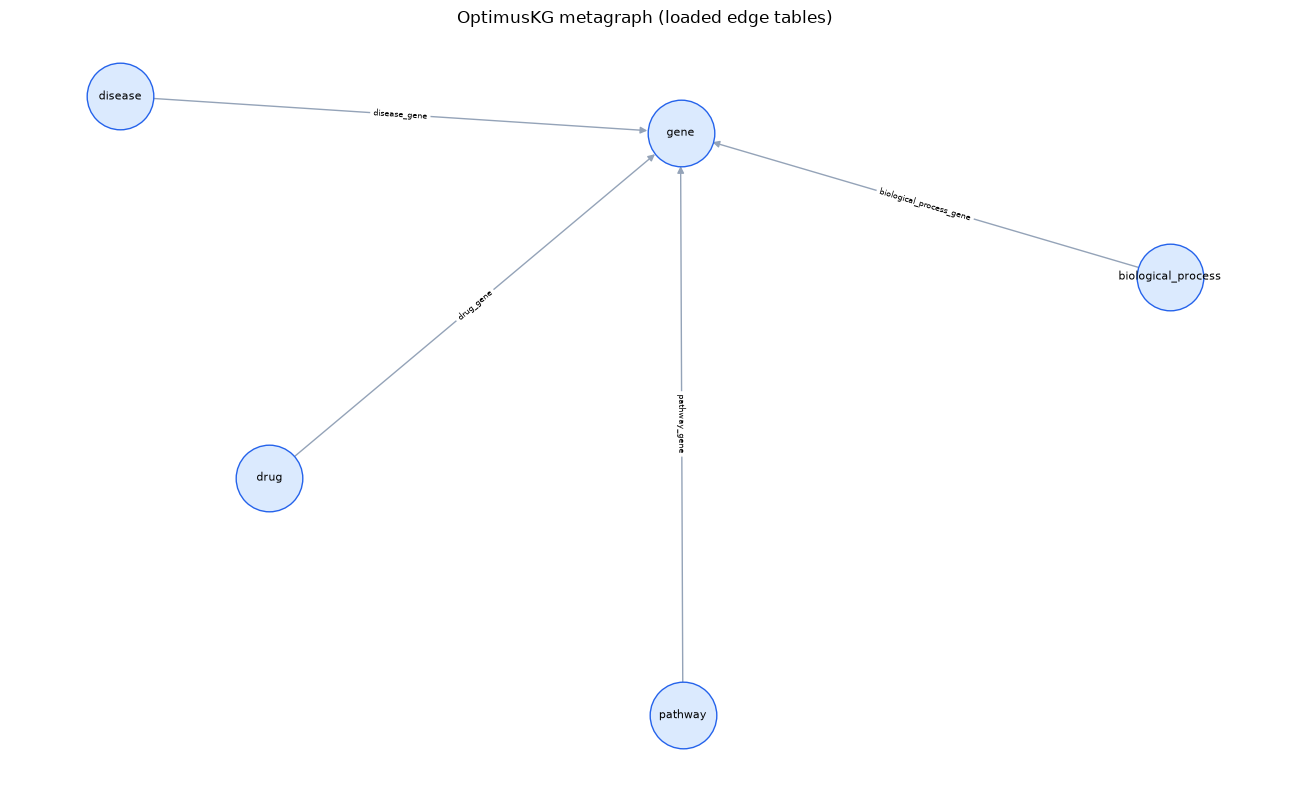

In [8]:
LOAD_SPECS = [
    ("node", "biological_process"),
    ("edge", "biological_process_gene"),
    ("node", "pathway"),
    ("edge", "pathway_gene"),
    ("node", "disease"),
    ("edge", "disease_gene"),
    ("node", "drug"),
    ("edge", "drug_gene"),
]

for kind, dataset in LOAD_SPECS:
    if dataset not in kg.tables:
        if kind == "node":
            kg.load_node(dataset)
        else:
            kg.load_edge(dataset)

display(kg.loaded())
kg.plot_metagraph(scope="loaded")
plt.show()


## 5. Typed neighbourhood inventory


In [9]:
EDGE_TYPES = [
    "biological_process_gene",
    "pathway_gene",
    "disease_gene",
    "drug_gene",
]

neighbourhoods = {
    # Version 0.4 accepts either a single edge-table name or a list.
    edge_type: lgals3.neighbors(edge_types=edge_type, limit=None)
    for edge_type in EDGE_TYPES
}

neighbour_inventory = lgals3.edge_summary(
    edge_types=EDGE_TYPES,
    exclude_self=True,
)

display(neighbour_inventory)


edge_type,raw_edge_rows,neighbour_rows,unique_neighbours
str,u32,u32,u32
"""disease_gene""",2605,2605,2605
"""biological_process_gene""",27,27,27
"""drug_gene""",5,5,5
"""pathway_gene""",4,4,4


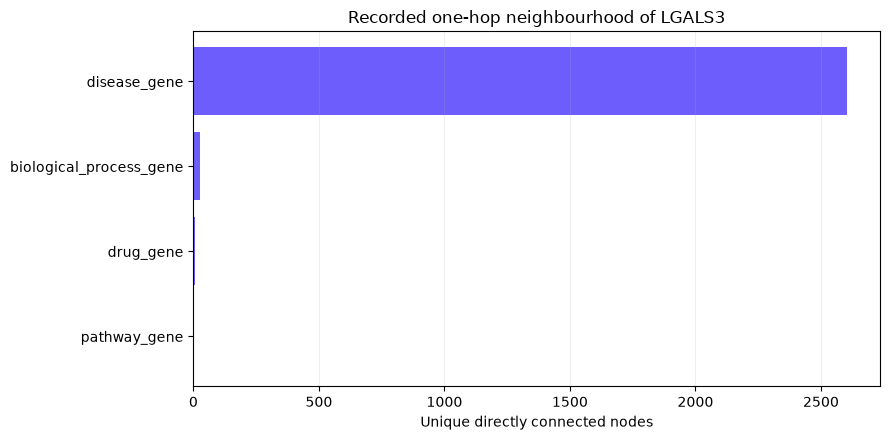

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
chart = neighbour_inventory.sort("unique_neighbours")
ax.barh(chart["edge_type"].to_list(), chart["unique_neighbours"].to_list(), color="#6d5dfc")
ax.set_xlabel("Unique directly connected nodes")
ax.set_title("Recorded one-hop neighbourhood of LGALS3")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


**Interpretation discipline:** these counts measure database connectivity. The
`disease` node table can contain diseases, traits, measurements and broad
ontology categories. A large count can reflect biological pleiotropy, ontology
structure, research attention or source coverage. It is not a count of diseases
caused by LGALS3.


## 6. Examine direct biological-process and pathway context


In [11]:
process_neighbours = neighbourhoods["biological_process_gene"].select(
    "neighbor_id", "neighbor_name", "relation"
).unique().sort("neighbor_name")

pathway_neighbours = neighbourhoods["pathway_gene"].select(
    "neighbor_id", "neighbor_name", "relation"
).unique().sort("neighbor_name")

display(process_neighbours)
display(pathway_neighbours)


neighbor_id,neighbor_name,relation
str,str,str
"""GO_0051132""","""NK T cell activation""","""INTERACTS_WITH"""
"""GO_0008380""","""RNA splicing""","""INTERACTS_WITH"""
"""GO_0030154""","""cell differentiation""","""INTERACTS_WITH"""
"""GO_0048245""","""eosinophil chemotaxis""","""INTERACTS_WITH"""
"""GO_0030855""","""epithelial cell differentiatio…","""INTERACTS_WITH"""
"""GO_0002376""","""immune system process""","""INTERACTS_WITH"""
"""GO_0045087""","""innate immune response""","""INTERACTS_WITH"""
"""GO_0006397""","""mRNA processing""","""INTERACTS_WITH"""
"""GO_0048246""","""macrophage chemotaxis""","""INTERACTS_WITH"""


neighbor_id,neighbor_name,relation
str,str,str
"""REACT:R-HSA-879415""","""Advanced glycosylation endprod…","""INTERACTS_WITH"""
"""REACT:R-HSA-6798695""","""Neutrophil degranulation""","""INTERACTS_WITH"""
"""REACT:R-HSA-8939246""","""RUNX1 regulates transcription …","""INTERACTS_WITH"""
"""REACT:R-HSA-8941333""","""RUNX2 regulates genes involved…","""INTERACTS_WITH"""


The following search finds *candidate vocabulary* for review. It does not define sterile inflammation. Word boundaries are used where possible so that, for example, `cytokinesis` is not mistaken for `cytokine`.


In [12]:
REVIEW_PATTERN = (
    r"(?i)(inflamm\w*|immune\b|cytokines?\b|macrophages?\b|"
    r"microglia\w*|leukocytes?\b|damage\w*|wound\w*|fibro\w*|"
    r"inflammasome\w*|pyropt\w*|necropt\w*|innate\b)"
)

candidate_process_terms = (
    process_neighbours
    .filter(pl.col("neighbor_name").str.contains(REVIEW_PATTERN))
    .with_columns(
        pl.lit(False).alias("include_in_module"),
        pl.lit("").alias("review_reason"),
        pl.lit("keyword candidate; not yet biologically reviewed").alias("status"),
    )
)

display(candidate_process_terms)


neighbor_id,neighbor_name,relation,include_in_module,review_reason,status
str,str,str,bool,str,str
"""GO_0002376""","""immune system process""","""INTERACTS_WITH""",false,"""""","""keyword candidate; not yet bio…"
"""GO_0045087""","""innate immune response""","""INTERACTS_WITH""",false,"""""","""keyword candidate; not yet bio…"
"""GO_0048246""","""macrophage chemotaxis""","""INTERACTS_WITH""",false,"""""","""keyword candidate; not yet bio…"


## 7. Build the direct LGALS3 disease-evidence table


In [13]:
disease_edges = (
    lgals3.edge_records(
        edge_types="disease_gene",
        direction="in",
        flatten_properties=True,
        limit=None,
    )
)

property_renames = {
    "properties__evidence_score": "evidence_score",
    "properties__evidence_count": "evidence_count",
    "properties__evidence_index": "evidence_index",
    "properties__disease_specificity_index": "disease_specificity_index",
    "properties__disease_pleiotropy_index": "disease_pleiotropy_index",
    "properties__disgenet_score": "disgenet_score",
    "properties__number_of_pmids": "number_of_pmids",
    "properties__number_of_snps": "number_of_snps",
    "properties__year_initial": "year_initial",
    "properties__year_final": "year_final",
    "properties__sources__direct": "direct_sources",
}
disease_edges = disease_edges.rename({
    old: new for old, new in property_renames.items()
    if old in disease_edges.columns
})

# This grouping is only a display aid. It is not an ontology classification.
disease_edges = disease_edges.with_columns(
    pl.col("neighbor_id").alias("disease_id"),
    pl.col("neighbor_name").alias("disease_name"),
    pl.col("neighbor_id").str.extract(r"^([^_:]+)", 1).alias("ontology_prefix"),
    pl.when(
        pl.col("neighbor_name").str.contains(
            r"(?i)(measurement|phenotype|trait|biomarker|count|level|volume|amount|percentage)"
        )
    )
    .then(pl.lit("trait / measurement candidate"))
    .otherwise(pl.lit("disease / other candidate"))
    .alias("display_group"),
)

disease_columns = [
    name for name in [
        "disease_name", "disease_id", "ontology_prefix", "display_group",
        "relation", "evidence_score",
        "evidence_count", "number_of_pmids", "number_of_snps",
        "disease_specificity_index", "disease_pleiotropy_index",
        "year_initial", "year_final", "direct_sources",
    ] if name in disease_edges.columns
]

disease_landscape = disease_edges.select(disease_columns)
sort_column = "evidence_score" if "evidence_score" in disease_landscape.columns else "disease_name"
disease_landscape = disease_landscape.sort(
    sort_column, descending=(sort_column != "disease_name"), nulls_last=True
)

display(disease_landscape.head(30))


disease_name,disease_id,ontology_prefix,display_group,relation,evidence_score,…,number_of_snps,disease_specificity_index,disease_pleiotropy_index,year_initial,year_final,direct_sources
str,str,str,str,str,f64,…,i16,f64,f64,str,str,list[str]
"""measurement""","""EFO_0001444""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.511795,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""protein measurement""","""EFO_0004747""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.476436,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""blood protein measurement""","""EFO_0007937""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.443262,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""galectin-3 measurement""","""EFO_0008137""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.438415,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""hematological measurement""","""EFO_0004503""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.434834,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""phenotype""","""EFO_0000651""","""EFO""","""trait / measurement candidate""","""ASSOCIATED_WITH""",0.401858,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""musculoskeletal or connective …","""OTAR_0000006""","""OTAR""","""disease / other candidate""","""ASSOCIATED_WITH""",0.393574,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""musculoskeletal system disease""","""EFO_0009676""","""EFO""","""disease / other candidate""","""ASSOCIATED_WITH""",0.393574,…,null,null,null,null,null,"[""OPEN_TARGETS""]"
"""skeletal system disease""","""EFO_0002461""","""EFO""","""disease / other candidate""","""ASSOCIATED_WITH""",0.393145,…,null,null,null,null,null,"[""OPEN_TARGETS""]"


`edge_records(..., flatten_properties=True)` now performs the reusable Struct
expansion that previously required notebook-local helper functions. The
`display_group` column is deliberately labelled as a candidate grouping: proper
classification should use ontology identifiers and expert-reviewed rules.


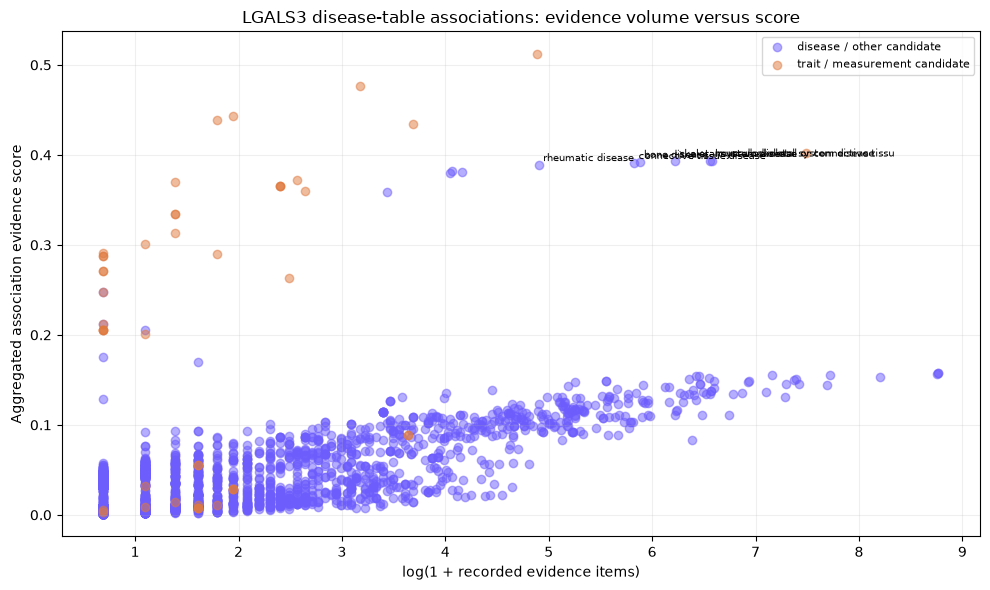

In [14]:
if {"evidence_score", "evidence_count"}.issubset(disease_landscape.columns):
    plot_data = disease_landscape.drop_nulls(["evidence_score", "evidence_count"])
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {
        "disease / other candidate": "#6d5dfc",
        "trait / measurement candidate": "#e07a3f",
    }
    for group, color in colors.items():
        subset = plot_data.filter(pl.col("display_group") == group)
        ax.scatter(
            [math.log1p(value) for value in subset["evidence_count"].to_list()],
            subset["evidence_score"].to_list(),
            alpha=0.5, color=color, label=group,
        )
    for row in (
        plot_data
        .filter(pl.col("display_group") == "disease / other candidate")
        .sort("evidence_score", descending=True)
        .head(6)
        .iter_rows(named=True)
    ):
        ax.annotate(
            str(row["disease_name"])[:35],
            (math.log1p(row["evidence_count"]), row["evidence_score"]),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points",
        )
    ax.set_xlabel("log(1 + recorded evidence items)")
    ax.set_ylabel("Aggregated association evidence score")
    ax.set_title("LGALS3 disease-table associations: evidence volume versus score")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("The selected release does not expose both evidence_score and evidence_count.")


This chart does not rank diseases by biological importance. It asks whether evidence volume and the source-derived association score tell the same story, and helps select records for manual provenance review.


## 8. Inspect recorded LGALS3 drug relationships


In [15]:
drug_edges = (
    lgals3.edge_records(
        edge_types="drug_gene",
        direction="in",
        flatten_properties=True,
        limit=None,
    )
)

drug_property_renames = {
    "neighbor_id": "drug_id",
    "neighbor_name": "drug_name",
    "properties__mechanisms_of_action": "mechanisms_of_action",
    "properties__source_ids": "source_ids",
    "properties__source_urls": "source_urls",
    "properties__sources__direct": "direct_sources",
}
drug_edges = drug_edges.rename({
    old: new for old, new in drug_property_renames.items()
    if old in drug_edges.columns
})

drug_columns = [
    name for name in [
        "drug_name", "drug_id", "relation", "mechanisms_of_action",
        "source_ids", "source_urls", "direct_sources",
    ] if name in drug_edges.columns
]

display(drug_edges.select(drug_columns).sort("drug_name"))


drug_name,drug_id,relation,mechanisms_of_action,source_ids,source_urls,direct_sources
str,str,str,list[str],list[str],list[str],list[str]
"""2,3,5,6-Tetrafluoro-4-Methoxy-…","""DRUGBANK:DB01827""","""TARGET""",null,null,null,"[""DRUG_BANK""]"
"""BELAPECTIN""","""CHEMBL4297577""","""INHIBITOR""","[""Galectin-3 inhibitor""]","[""31812510"", ""https://galectintherapeutics.com/about-belapectin/""]","[""http://europepmc.org/abstract/MED/31812510"", ""https://galectintherapeutics.com/about-belapectin/""]","[""OPEN_TARGETS""]"
"""DAVANAT""","""CHEMBL4297960""","""INHIBITOR""","[""Galectin-3 inhibitor""]","[""29320431"", ""https://investor.galectintherapeutics.com/news-releases/news-release-details/pro-pharmaceuticals-announces-significant-advance-defining""]","[""http://europepmc.org/abstract/MED/29320431"", ""https://investor.galectintherapeutics.com/news-releases/news-release-details/pro-pharmaceuticals-announces-significant-advance-defining""]","[""OPEN_TARGETS""]"
"""Lactose""","""DRUGBANK:DB04465""","""TARGET""",null,null,null,"[""DRUG_BANK""]"
"""OLITIGALTIN""","""CHEMBL4297442""","""INHIBITOR""","[""Galectin-3 inhibitor""]","[""23752421"", ""NCT03832946"", … ""https://www.atsjournals.org/doi/abs/10.1164/ajrccm-conference.2017.195.1_MeetingAbstracts.A7560""]","[""http://europepmc.org/abstract/MED/23752421"", ""https://galecto.com/galecto-biotechs-lead-molecule-td139-is-safe-well-tolerated-with-direct-target-engagement-and-biomarker-effects-in-a-clinical-phase-ibiia-trial-in-ipf-patients/"", … ""https://www.clinicaltrials.gov/ct2/show/NCT03832946""]","[""OPEN_TARGETS""]"


The relation type matters. `INHIBITOR`, `AGONIST`, `BINDING_AGENT` and generic `TARGET` assertions are not interchangeable. Mechanism descriptions and source records should be inspected before grouping them.


## 9. A first graph-theoretic application: typed neighbourhood overlap


We now ask a relational question that cannot be answered by looking at LGALS3 alone:

> Which recorded LGALS3-interacting genes share the largest fraction of its biological-process neighbourhood?

For two genes, process-neighbourhood Jaccard similarity is:

\[
J(A,B)=\frac{|P_A \cap P_B|}{|P_A \cup P_B|}
\]

This is a transparent baseline. It measures shared annotation context, not functional equivalence or causal regulation.


In [16]:
if "gene_gene" not in kg.tables:
    kg.load_edge("gene_gene")

self_loop_audit = (
    kg.tables["gene_gene"]
    .filter(
        (pl.col("from").cast(pl.String) == lgals3.id)
        & (pl.col("to").cast(pl.String) == lgals3.id)
    )
)

ppi_neighbours = (
    lgals3.neighbors(
        edge_types="gene_gene", limit=None, exclude_self=True,
    )
    .filter(pl.col("neighbor_type") == "gene")
    .select("neighbor_id", "neighbor_name")
    .unique("neighbor_id")
)

print(f"Returned LGALS3 self-edge records (before exclusion): {self_loop_audit.height:,}")
print(f"Other direct LGALS3 gene-interaction neighbours: {ppi_neighbours.height:,}")
display(ppi_neighbours.head(20))


Returned LGALS3 self-edge records (before exclusion): 1
Other direct LGALS3 gene-interaction neighbours: 156


neighbor_id,neighbor_name
str,str
"""ENSG00000115414""","""fibronectin 1"""
"""ENSG00000008282""","""synaptophysin like 1"""
"""ENSG00000091136""","""laminin subunit beta 1"""
"""ENSG00000091513""","""transferrin"""
"""ENSG00000204475""","""natural cytotoxicity triggerin…"
"""ENSG00000101266""","""casein kinase 2 alpha 1"""
"""ENSG00000113712""","""casein kinase 1 alpha 1"""
"""ENSG00000128567""","""podocalyxin like"""
"""ENSG00000186907""","""reticulon 4 receptor like 2"""


In [17]:
candidate_gene_ids = [lgals3.id] + ppi_neighbours["neighbor_id"].to_list()

membership = (
    kg.tables["biological_process_gene"]
    .filter(pl.col("to").cast(pl.String).is_in(candidate_gene_ids))
    .select(
        pl.col("to").cast(pl.String).alias("gene_id"),
        pl.col("from").cast(pl.String).alias("process_id"),
    )
    .unique()
)

process_sets = {
    gene_id: set(group["process_id"].to_list())
    for (gene_id,), group in membership.group_by("gene_id")
}

lgals3_processes = process_sets.get(lgals3.id, set())
name_map = dict(zip(
    ppi_neighbours["neighbor_id"].to_list(),
    ppi_neighbours["neighbor_name"].to_list(),
))

similarity_records = []
for gene_id in ppi_neighbours["neighbor_id"].to_list():
    other = process_sets.get(gene_id, set())
    intersection = lgals3_processes & other
    union = lgals3_processes | other
    similarity_records.append({
        "gene_id": gene_id,
        "gene_name": name_map.get(gene_id, gene_id),
        "shared_processes": len(intersection),
        "gene_processes": len(other),
        "lgals3_processes": len(lgals3_processes),
        "jaccard_similarity": len(intersection) / len(union) if union else 0.0,
    })

process_similarity = (
    pl.DataFrame(similarity_records)
    .sort(["jaccard_similarity", "shared_processes"], descending=True)
)

display(process_similarity.head(20))


gene_id,gene_name,shared_processes,gene_processes,lgals3_processes,jaccard_similarity
str,str,i64,i64,i64,f64
"""ENSG00000179409""","""gem nuclear organelle associat…",2,4,27,0.068966
"""ENSG00000074201""","""chloride nucleotide-sensitive …",2,7,27,0.0625
"""ENSG00000125835""","""small nuclear ribonucleoprotei…",2,7,27,0.0625
"""ENSG00000204475""","""natural cytotoxicity triggerin…",2,8,27,0.060606
"""ENSG00000013725""","""CD6 molecule""",2,11,27,0.055556
"""ENSG00000135316""","""synaptotagmin binding cytoplas…",2,11,27,0.055556
"""ENSG00000135404""","""CD63 molecule""",2,16,27,0.04878
"""ENSG00000164509""","""interleukin 31 receptor A""",2,19,27,0.045455
"""ENSG00000149177""","""protein tyrosine phosphatase r…",3,45,27,0.043478


### Questions to ask of the result

- Does a high score come from several specific processes or a few broad ontology terms?
- Would the ranking change if broad parent terms were removed?
- Are the gene–gene relationships physical interactions, functional associations or mixed assertions?
- Does the result survive minimum evidence requirements?
- Are the relevant processes active in the tissue or cell type of interest?


## 10. Plot a small, readable representative subgraph


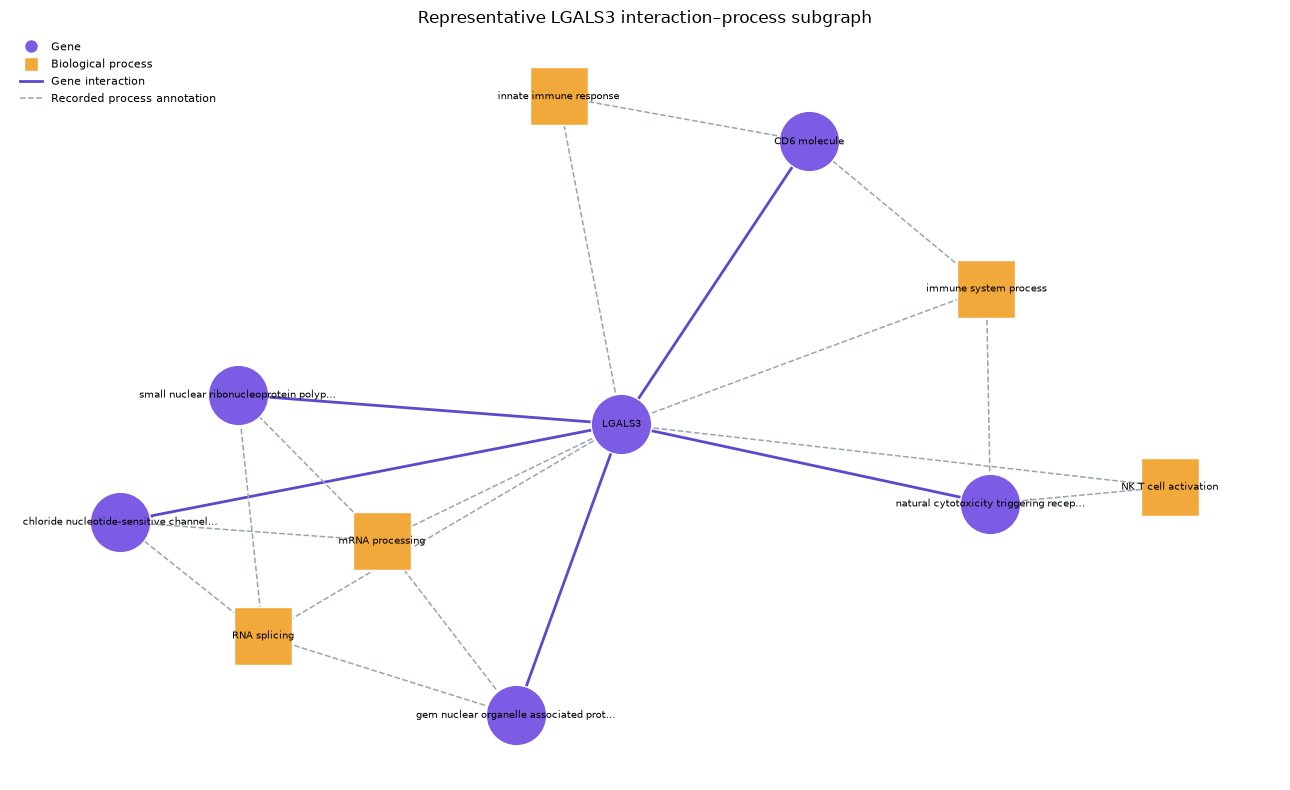

: 

In [ ]:
TOP_GENES = 5
MAX_SHARED_PROCESSES_PER_GENE = 3

top_gene_ids = process_similarity.head(TOP_GENES)["gene_id"].to_list()

process_name_map = dict(zip(
    process_neighbours["neighbor_id"].to_list(),
    process_neighbours["neighbor_name"].to_list(),
))

G = nx.Graph()
G.add_node(lgals3.id, label="LGALS3", node_type="gene")

for gene_id in top_gene_ids:
    gene_label = name_map.get(gene_id, gene_id)
    G.add_node(gene_id, label=gene_label, node_type="gene")
    G.add_edge(lgals3.id, gene_id, edge_type="gene interaction")

    shared = sorted(
        lgals3_processes & process_sets.get(gene_id, set()),
        key=lambda process_id: process_name_map.get(process_id, process_id),
    )
    for process_id in shared[:MAX_SHARED_PROCESSES_PER_GENE]:
        process_label = process_name_map.get(process_id, process_id)
        G.add_node(process_id, label=process_label, node_type="biological_process")
        G.add_edge(gene_id, process_id, edge_type="annotated to")
        G.add_edge(lgals3.id, process_id, edge_type="annotated to")

fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(G, seed=9, k=1.2)

gene_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "gene"]
process_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "biological_process"]

nx.draw_networkx_nodes(
    G, pos, nodelist=gene_nodes, node_color="#7c5ce5", node_shape="o",
    node_size=1900, edgecolors="white", ax=ax,
)
nx.draw_networkx_nodes(
    G, pos, nodelist=process_nodes, node_color="#f2a93b", node_shape="s",
    node_size=1700, edgecolors="white", ax=ax,
)
interaction_edges = [
    (u, v) for u, v, data in G.edges(data=True)
    if data["edge_type"] == "gene interaction"
]
annotation_edges = [
    (u, v) for u, v, data in G.edges(data=True)
    if data["edge_type"] == "annotated to"
]
nx.draw_networkx_edges(
    G, pos, edgelist=interaction_edges,
    edge_color="#5b4acb", width=2.0, ax=ax,
)
nx.draw_networkx_edges(
    G, pos, edgelist=annotation_edges,
    edge_color="#9aa4b2", width=1.1, style="dashed", ax=ax,
)

labels = {
    node: (data["label"][:37] + "…" if len(data["label"]) > 38 else data["label"])
    for node, data in G.nodes(data=True)
}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)

ax.set_title("Representative LGALS3 interaction–process subgraph")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#7c5ce5",
           markersize=10, label="Gene"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#f2a93b",
           markersize=10, label="Biological process"),
    Line2D([0], [0], color="#5b4acb", lw=2, label="Gene interaction"),
    Line2D([0], [0], color="#9aa4b2", lw=1.1, linestyle="--",
           label="Recorded process annotation"),
], loc="upper left", frameon=False, fontsize=8)
ax.axis("off")
plt.tight_layout()
plt.show()


This visual is deliberately selective. It shows the highest process-overlap interaction neighbours and a few shared contexts. The complete tables remain the evidence record; the figure is a communication layer.


## 11. Hand-off to a future sterile-inflammation module


In [ ]:
analysis_tables = {
    "lgals3_candidate_sterile_process_terms": candidate_process_terms,
    "lgals3_disease_landscape": disease_landscape,
    "lgals3_drug_relations": drug_edges.select(drug_columns),
    "lgals3_interactor_process_similarity": process_similarity,
}

for name, frame in analysis_tables.items():
    kg.export_table(frame, OUTPUT_DIR / f"{name}.csv")
    kg.export_table(frame, OUTPUT_DIR / f"{name}.parquet")

# A normalized one-hop evidence package for BI tools and downstream analysis.
bundle = lgals3.export_neighborhood(
    OUTPUT_DIR / "lgals3_one_hop_evidence_bundle",
    radius=1,
    edge_types=[
        "biological_process_gene", "pathway_gene", "disease_gene",
        "drug_gene", "gene_gene",
    ],
    max_neighbors_per_hop=5000,
    exclude_self=True,
    formats=["csv", "parquet", "duckdb"],
)

display(bundle.summary())
display(pl.DataFrame([bundle.manifest]))
print("Saved analysis tables and evidence bundle to:", OUTPUT_DIR)


The evidence bundle separates `entities`, `relationships`, and flattened
`evidence`. CSV files are intended for BI tools; Parquet preserves richer data
types; DuckDB provides a portable local SQL database. The manifest records the
seed, release, traversal boundary, counts, and whether expansion was truncated.


### Review task before Part 2

Open `lgals3_candidate_sterile_process_terms.csv` and review each candidate with a domain colleague. For every retained term, record:

- why it represents sterile rather than pathogen-driven inflammation;
- which phase it represents: damage, sensing, amplification, recruitment, resolution or fibrosis;
- whether it is general or anatomy/cell specific;
- supporting reference;
- whether it should be a core term or contextual term.

That reviewed table can become one input to a broader sterile-inflammation module. A valid module should also include important terms that are not currently connected to LGALS3; otherwise the definition would be circular and guaranteed to make Galectin-3 appear central.


## 12. Student reflection questions

1. Which search matches referred to LGALS3 itself, and which were related terms or synonyms?
2. Which relationship type produced the largest LGALS3 neighbourhood? What are at least three possible explanations?
3. Do evidence score and evidence count rank diseases similarly?
4. Which drug relationships describe directional action, and which merely identify a target or binding relationship?
5. Which interacting genes have high process overlap with LGALS3? Are the shared terms specific enough to interpret?
6. What changes if parent or generic biological-process terms are removed?
7. Which observations are recorded evidence, derived graph observations and hypotheses?
8. What extra data would be required before calling any displayed path causal?

### Suggested one-paragraph conclusion template

> In the pinned OptimusKG release, LGALS3 was connected to **[counts]** across the selected relationship types. The graph made it possible to move from an exact gene identity to traceable disease, drug and functional contexts. A typed neighbourhood-overlap analysis highlighted **[genes]**, although the result was sensitive to **[broad terms, degree or evidence limitations]**. Keyword filtering identified **[number]** candidate inflammation-related process terms, but these remain vocabulary candidates pending biological review. The analysis therefore provides an auditable evidence landscape and a starting point for a separately defined sterile-inflammation study, not evidence that LGALS3 or its recorded compounds cause or treat a particular condition.


## References and next step

- [OptimusKG paper](https://arxiv.org/abs/2604.27269)
- [OptimusKG graph schema](https://optimuskg.ai/docs/graph-schema/edges)
- [KnetMiner: evidence-based gene discovery and graph exploration](https://pmc.ncbi.nlm.nih.gov/articles/PMC8244015/)
- [Sterile inflammation: sensing and reacting to damage](https://pmc.ncbi.nlm.nih.gov/articles/PMC3114424/)
- [Galectin-3 neutralisation in inflammatory and fibrotic biology](https://www.nature.com/articles/s41467-023-41117-9)
- [RPath: causal paths plus transcriptomic signatures](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1009909)

The recommended next notebook is **Part 2: Defining and Auditing a Sterile-Inflammation Module**. It should begin with an independently reviewed module, compare multiple disease or injury contexts, and only then introduce degree-matched backgrounds and compound prioritisation.
